In [17]:
import pandas as pd
import numpy as np

In [18]:
#Load Dataset
df = pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [19]:
print(df.shape)
print(df.info())
print(df.isnull().sum().sum(), "Missing Values")

(1470, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel     

In [20]:
#Drop Constant/useless columns
Constant_cols = ['EmployeeCount','Over18','StandardHours','EmployeeNumber']
df = df.drop(columns=[c for c in Constant_cols if c in df.columns])

In [21]:
#check Target balance
print(df['Attrition'].value_counts(normalize=True))

Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


In [22]:
# Convert target to binary for ML later, keep a readable copy for BI
df['AttritionFlag'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [23]:
# Quick sanity check on categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols)

['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [24]:
# Export clean version — this feeds both Python EDA and Power BI
df.to_csv('hr_attrition_clean.csv', index=False)

In [25]:
df['Attrition'].value_counts(normalize=True)

,proportion
Attrition,
No,0.838776
Yes,0.161224


Overall attrition rate: 16.1%

Attrition by Department:
 Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: AttritionFlag, dtype: float64

Attrition by OverTime:
 OverTime
No     10.436433
Yes    30.528846
Name: AttritionFlag, dtype: float64

Attrition by Job Role:
 JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: AttritionFlag, dtype: float64

Avg Monthly Income (Leavers vs Stayers):
 Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64

Avg Years at Company (Leavers vs Stayers):
 Attrition
No     7.369019
Yes    5.130802
Name: YearsAtCompany, dtype: float64

Avg Distance

/tmp/ipykernel_2407/2028523255.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_attr.index, y=dept_attr.values, ax=axes[0,0], palette='viridis')
/tmp/ipykernel_2407/2028523255.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ot_attr.index, y=ot_attr.values, ax=axes[0,1], palette='magma')
/tmp/ipykernel_2407/2028523255.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=role_attr.values, y=role_attr.index, ax=axes[0,2], palette='rocket')
/tmp/ipykernel_2407/2028523255.py:57: FutureWarning: 

Passing `palette` without assig

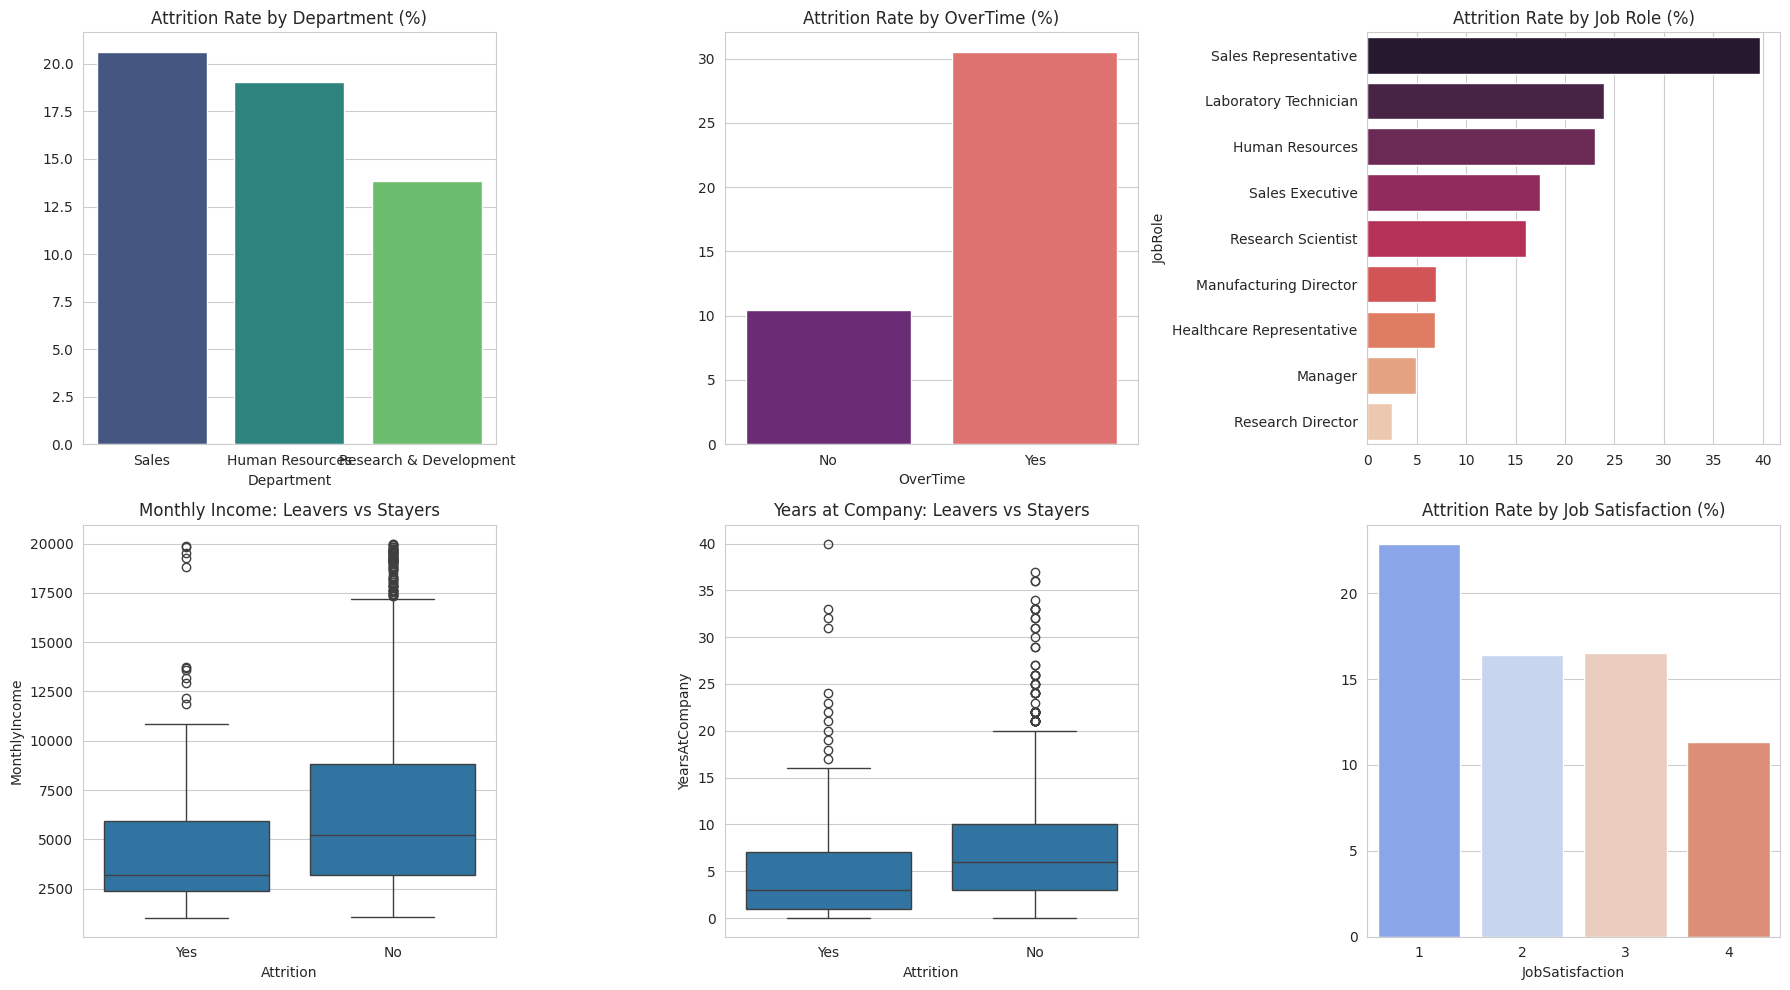

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
df = pd.read_csv('hr_attrition_clean.csv')

# 1. Overall attrition rate
attrition_rate = df['AttritionFlag'].mean() * 100
print(f"Overall attrition rate: {attrition_rate:.1f}%")

# 2. Attrition by Department
dept_attr = df.groupby('Department')['AttritionFlag'].mean().sort_values(ascending=False) * 100
print("\nAttrition by Department:\n", dept_attr)

# 3. Attrition by OverTime
ot_attr = df.groupby('OverTime')['AttritionFlag'].mean() * 100
print("\nAttrition by OverTime:\n", ot_attr)

# 4. Attrition by Job Role (top drivers)
role_attr = df.groupby('JobRole')['AttritionFlag'].mean().sort_values(ascending=False) * 100
print("\nAttrition by Job Role:\n", role_attr)

# 5. Income comparison: leavers vs stayers
income_compare = df.groupby('Attrition')['MonthlyIncome'].mean()
print("\nAvg Monthly Income (Leavers vs Stayers):\n", income_compare)

# 6. Tenure comparison
tenure_compare = df.groupby('Attrition')['YearsAtCompany'].mean()
print("\nAvg Years at Company (Leavers vs Stayers):\n", tenure_compare)

# 7. Distance from home
dist_compare = df.groupby('Attrition')['DistanceFromHome'].mean()
print("\nAvg Distance From Home (Leavers vs Stayers):\n", dist_compare)

# 8. Job satisfaction
satisf_attr = df.groupby('JobSatisfaction')['AttritionFlag'].mean() * 100
print("\nAttrition by Job Satisfaction level:\n", satisf_attr)

# --- Now the charts ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.barplot(x=dept_attr.index, y=dept_attr.values, ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Attrition Rate by Department (%)')

sns.barplot(x=ot_attr.index, y=ot_attr.values, ax=axes[0,1], palette='magma')
axes[0,1].set_title('Attrition Rate by OverTime (%)')

sns.barplot(x=role_attr.values, y=role_attr.index, ax=axes[0,2], palette='rocket')
axes[0,2].set_title('Attrition Rate by Job Role (%)')

sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, ax=axes[1,0])
axes[1,0].set_title('Monthly Income: Leavers vs Stayers')

sns.boxplot(x='Attrition', y='YearsAtCompany', data=df, ax=axes[1,1])
axes[1,1].set_title('Years at Company: Leavers vs Stayers')

sns.barplot(x=satisf_attr.index, y=satisf_attr.values, ax=axes[1,2], palette='coolwarm')
axes[1,2].set_title('Attrition Rate by Job Satisfaction (%)')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150)
plt.show()

**Key Findings**


*   **Overtime is the single biggest driver** - 30.5% attrition for employees working overtime vs 10.4% for those who don't (3x difference)
*   **Sales Representatives leave at a shocking 40% rate** - by far the highest of any role
*   **Sales department overall (20.6%)** has notably higher attrition than R&D (13.8%)
*   **Pay gap is real**: leavers earn ₹4,787 avg vs ₹6,833 for stayers - a ~30% gap
*    **Distance matters**: leavers live ~10.6 km away vs 8.9 km for stayers
*    **Tenure**: leavers average 5.1 years vs 7.4 years - newer employees churn more
*    **Satisfaction is a clean gradient** - attrition drops steadily from 22.8% (satisfaction=1) to 11.3% (satisfaction=4)

In [12]:
# Add this in Colab before re-exporting, or as a DAX calculated column in Power BI
def risk_flag(row):
    score = 0
    if row['OverTime'] == 'Yes': score += 1
    if row['JobSatisfaction'] <= 2: score += 1
    if row['MonthlyIncome'] < df['MonthlyIncome'].median(): score += 1
    if row['DistanceFromHome'] > 15: score += 1
    return 'High Risk' if score >= 2 else 'Low Risk'

df['RiskCategory'] = df.apply(risk_flag, axis=1)
df.to_csv('hr_attrition_clean.csv', index=False)

In [13]:
print(df['RiskCategory'].value_counts())

RiskCategory
Low Risk     824
High Risk    646
Name: count, dtype: int64


In [14]:
 df.to_csv('hr_attrition_clean.csv', index=False)

In [15]:
##SQL QUeries
import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql('hr_attrition', conn, index=False, if_exists='replace')

queries = {
"1. Attrition rate by department": """
    SELECT Department,
           ROUND(AVG(AttritionFlag)*100, 2) AS attrition_rate_pct,
           COUNT(*) AS headcount
    FROM hr_attrition GROUP BY Department ORDER BY attrition_rate_pct DESC;
""",

"2. Avg income: high risk vs low risk": """
    SELECT RiskCategory, ROUND(AVG(MonthlyIncome),0) AS avg_income, COUNT(*) AS headcount
    FROM hr_attrition GROUP BY RiskCategory;
""",

"3. Headcount by risk category and job role": """
    SELECT JobRole, RiskCategory, COUNT(*) AS headcount
    FROM hr_attrition GROUP BY JobRole, RiskCategory ORDER BY JobRole;
""",

"4. Overtime distribution within high-risk group": """
    SELECT OverTime, COUNT(*) AS headcount
    FROM hr_attrition WHERE RiskCategory='High Risk' GROUP BY OverTime;
""",

"5. Top 5 roles by high-risk %": """
    SELECT JobRole,
           ROUND(100.0*SUM(CASE WHEN RiskCategory='High Risk' THEN 1 ELSE 0 END)/COUNT(*), 2) AS high_risk_pct,
           COUNT(*) AS headcount
    FROM hr_attrition GROUP BY JobRole ORDER BY high_risk_pct DESC LIMIT 5;
""",

"6. Avg tenure: leavers vs stayers": """
    SELECT Attrition, ROUND(AVG(YearsAtCompany),1) AS avg_tenure
    FROM hr_attrition GROUP BY Attrition;
""",

"7. Attrition rate by job satisfaction level": """
    SELECT JobSatisfaction, ROUND(AVG(AttritionFlag)*100,2) AS attrition_rate_pct
    FROM hr_attrition GROUP BY JobSatisfaction ORDER BY JobSatisfaction;
""",

"8. Avg distance from home: high risk vs low risk": """
    SELECT RiskCategory, ROUND(AVG(DistanceFromHome),1) AS avg_distance_km
    FROM hr_attrition GROUP BY RiskCategory;
""",

"9. Gender breakdown of high-risk employees": """
    SELECT Gender, COUNT(*) AS headcount
    FROM hr_attrition WHERE RiskCategory='High Risk' GROUP BY Gender;
""",

"10. Department x risk category matrix": """
    SELECT Department, RiskCategory, COUNT(*) AS headcount,
           ROUND(100.0*COUNT(*)/SUM(COUNT(*)) OVER (PARTITION BY Department), 1) AS pct_within_dept
    FROM hr_attrition GROUP BY Department, RiskCategory ORDER BY Department;
"""
}

for title, q in queries.items():
    print(f"\n{'='*60}\n{title}\n{'='*60}")
    print(pd.read_sql_query(q, conn))


1. Attrition rate by department
               Department  attrition_rate_pct  headcount
0                   Sales               20.63        446
1         Human Resources               19.05         63
2  Research & Development               13.84        961

2. Avg income: high risk vs low risk
  RiskCategory  avg_income  headcount
0    High Risk      4758.0        646
1     Low Risk      7871.0        824

3. Headcount by risk category and job role
                      JobRole RiskCategory  headcount
0   Healthcare Representative    High Risk         35
1   Healthcare Representative     Low Risk         96
2             Human Resources    High Risk         27
3             Human Resources     Low Risk         25
4       Laboratory Technician    High Risk        157
5       Laboratory Technician     Low Risk        102
6                     Manager    High Risk         18
7                     Manager     Low Risk         84
8      Manufacturing Director    High Risk         49
9  

**ML MODEL**

In [16]:
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv('hr_attrition_clean.csv')

# Drop columns that shouldn't be features
drop_cols = ['Attrition', 'AttritionFlag', 'RiskCategory']
X = df.drop(columns=drop_cols)
y = df['AttritionFlag']

# One-hot encode categorical columns
X = pd.get_dummies(X, drop_first=True)

print("Feature matrix shape:", X.shape)
print("Target balance:\n", y.value_counts(normalize=True))

# Train/test split, stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain shape:", X_train.shape, "Test shape:", X_test.shape)

Feature matrix shape: (1470, 44)
Target balance:
 AttritionFlag
0    0.838776
1    0.161224
Name: proportion, dtype: float64

Train shape: (1176, 44) Test shape: (294, 44)


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Scale features (helps Logistic Regression converge and perform better)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)
y_proba = log_model.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1:", round(f1_score(y_test, y_pred), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

=== Logistic Regression ===
Accuracy: 0.7517
ROC-AUC: 0.7983
Precision: 0.3452
Recall: 0.617
F1: 0.4427

Confusion Matrix:
 [[192  55]
 [ 18  29]]


In [27]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Random Forest
rf_model = RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)  # tree models don't need scaling
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print("Accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, rf_proba), 4))
print("Precision:", round(precision_score(y_test, rf_pred), 4))
print("Recall:", round(recall_score(y_test, rf_pred), 4))
print("F1:", round(f1_score(y_test, rf_pred), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, rf_pred))

# XGBoost — compute scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

print("\n=== XGBoost ===")
print("Accuracy:", round(accuracy_score(y_test, xgb_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, xgb_proba), 4))
print("Precision:", round(precision_score(y_test, xgb_pred), 4))
print("Recall:", round(recall_score(y_test, xgb_pred), 4))
print("F1:", round(f1_score(y_test, xgb_pred), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, xgb_pred))

=== Random Forest ===
Accuracy: 0.8367
ROC-AUC: 0.7707
Precision: 0.4444
Recall: 0.0851
F1: 0.1429

Confusion Matrix:
 [[242   5]
 [ 43   4]]

=== XGBoost ===
Accuracy: 0.8401
ROC-AUC: 0.7368
Precision: 0.5
Recall: 0.3191
F1: 0.3896

Confusion Matrix:
 [[232  15]
 [ 32  15]]


In [28]:
import numpy as np

# Get coefficients and match them to feature names
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
})

# Sort by absolute value to see strongest predictors (positive or negative)
coef_df['AbsCoef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('AbsCoef', ascending=False)

print("Top 15 features driving attrition prediction:\n")
print(coef_df.head(15)[['Feature', 'Coefficient']].to_string(index=False))

Top 15 features driving attrition prediction:

                         Feature  Coefficient
   JobRole_Laboratory Technician     0.810172
                    OverTime_Yes     0.771095
BusinessTravel_Travel_Frequently     0.722538
               TotalWorkingYears    -0.660270
                        JobLevel     0.650173
    JobRole_Sales Representative     0.531090
    BusinessTravel_Travel_Rarely     0.512780
    EducationField_Life Sciences    -0.512319
         YearsSinceLastPromotion     0.499063
                Department_Sales     0.470587
              NumCompaniesWorked     0.464327
            YearsWithCurrManager    -0.461322
            MaritalStatus_Single     0.455366
          EducationField_Medical    -0.452134
         EnvironmentSatisfaction    -0.434370


In [29]:
# Get predicted probability of attrition for ALL employees (not just test set)
X_full_scaled = scaler.transform(X)
df['PredictedRiskProb'] = log_model.predict_proba(X_full_scaled)[:, 1]

# Bucket into risk tiers
def risk_tier(p):
    if p >= 0.5:
        return 'High Risk'
    elif p >= 0.25:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['PredictedRiskTier'] = df['PredictedRiskProb'].apply(risk_tier)

print(df['PredictedRiskTier'].value_counts())
print("\nSample:\n", df[['EmployeeNumber' if 'EmployeeNumber' in df.columns else df.columns[0], 'Attrition', 'PredictedRiskProb', 'PredictedRiskTier']].head(10) if 'EmployeeNumber' in df.columns else df[['Attrition','PredictedRiskProb','PredictedRiskTier']].head(10))

# Export for Power BI v2
df.to_csv('hr_attrition_with_ml_risk.csv', index=False)

PredictedRiskTier
Low Risk       700
High Risk      456
Medium Risk    314
Name: count, dtype: int64

Sample:
   Attrition  PredictedRiskProb PredictedRiskTier
0       Yes           0.903032         High Risk
1        No           0.112662          Low Risk
2       Yes           0.723529         High Risk
3        No           0.370366       Medium Risk
4        No           0.834703         High Risk
5        No           0.271686       Medium Risk
6        No           0.440245       Medium Risk
7        No           0.308231       Medium Risk
8        No           0.370336       Medium Risk
9        No           0.136320          Low Risk
